# Seoul Bike Sharing Demand — Pré-processamento

**Integrantes da equipe:** Gabriel Albuquerque Alencar, Alberto Eduardo Acosta, Davi Maciel Corrêa

**Declaração de uso de IA Generativa**
- Ferramenta utilizada: Claude (Anthropic), via Claude Code.
- Finalidade do uso: apoio na escrita do script de pré-processamento (remoção de registros inválidos, criação de features) e na documentação em Markdown deste notebook.
- Extensão aproximada da contribuição: geração do código de limpeza/engenharia de atributos desta etapa (Decisões efetuadas pela equipe) do trabalho; as decisões de modelagem (etapas 3 em diante) ainda serão feitas pela equipe.
- Medidas de validação: os resultados de cada transformação foram conferidos manualmente (contagem de linhas antes/depois, `head()`, `dtypes`, checagem de valores nulos) antes de seguir para a próxima etapa.

> O arquivo original `SeoulBikeData.csv` é mantido como backup e **nunca é sobrescrito**; toda saída tratada é salva em um novo arquivo `SeoulBikeData_treated.csv`.

In [1]:
# Imports básicos para leitura, tratamento e visualização exploratória dos dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 1. Carregamento do dataset original

O arquivo `SeoulBikeData.csv` está codificado em **ISO-8859-1** (não é UTF-8 — por isso os símbolos de grau em `Temperature(°C)` aparecem corrompidos se lido com a codificação errada). Ele é lido aqui apenas para leitura; o arquivo em disco não é alterado — ele funciona como nosso **backup padrão**.

In [2]:
RAW_PATH = "SeoulBikeData.csv"

df = pd.read_csv(RAW_PATH, encoding="ISO-8859-1")

print("Formato original:", df.shape)
df.head()

Formato original: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
# Visão geral dos tipos de dados e de valores ausentes
df.info()
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

## 2. Remoção dos registros com `Functioning Day = No`

**Por quê:** `Functioning Day` indica se a estação de bicicletas estava operando naquele dia/hora. Quando o valor é `No`, o sistema estava fechado e `Rented Bike Count` é necessariamente `0` — não é uma observação real de demanda, e sim uma ausência de operação. Manter essas linhas introduziria um viés artificial (muitos zeros que não refletem falta de demanda, mas sim indisponibilidade do serviço), o que prejudicaria o treinamento da MLP na etapa de regressão.

**O que fazemos:** filtramos o DataFrame mantendo apenas as linhas em que `Functioning Day == "Yes"`, documentando quantos registros foram descartados.

In [4]:
n_antes = len(df)
n_no = (df["Functioning Day"] == "No").sum()

df = df[df["Functioning Day"] == "Yes"].reset_index(drop=True)

n_depois = len(df)
print(f"Registros antes:  {n_antes}")
print(f"Registros 'No' removidos: {n_no}")
print(f"Registros depois: {n_depois}")
assert n_antes - n_no == n_depois

Registros antes:  8760
Registros 'No' removidos: 295
Registros depois: 8465


## 3. Remoção da coluna `Functioning Day`

**Por quê:** depois do filtro acima, todos os registros restantes têm `Functioning Day == "Yes"`. A coluna virou uma constante (variância zero) e não carrega mais nenhuma informação útil para o modelo — por isso é descartada.

In [5]:
assert df["Functioning Day"].nunique() == 1, "Esperava-se apenas o valor 'Yes' restante"

df = df.drop(columns=["Functioning Day"])
df.columns.tolist()

['Date',
 'Rented Bike Count',
 'Hour',
 'Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature(°C)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Seasons',
 'Holiday']

## 4. Criação da coluna `IsWeekend`

**Por quê:** a coluna `Date` (formato `DD/MM/AAAA`) não é diretamente utilizável por uma MLP e, sozinha, tem alta cardinalidade (365 dias distintos). Uma das hipóteses da equipe é que **o volume de aluguéis difere entre dias de semana e finais de semana**. Para viabilizar essa análise (e permitir que o modelo capture esse padrão), criamos uma variável binária `IsWeekend`:

- `1` → sábado ou domingo
- `0` → segunda a sexta-feira

A coluna `Date` é convertida para `datetime` (`dayfirst=True`, pois o formato é dia/mês/ano) apenas para extrair o dia da semana; ela é mantida no DataFrame para referência/eventual engenharia de atributos futura (ex.: mês, estação), mas pode ser descartada depois caso não seja usada como entrada da MLP.

In [6]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# weekday(): 0 = segunda ... 5 = sábado, 6 = domingo
df["IsWeekend"] = df["Date"].dt.weekday.isin([5, 6]).astype(int)

df[["Date", "IsWeekend"]].drop_duplicates().head(10)

,Date,IsWeekend
0,2017-12-01,0
24,2017-12-02,1
48,2017-12-03,1
72,2017-12-04,0
96,2017-12-05,0
120,2017-12-06,0
144,2017-12-07,0
168,2017-12-08,0
192,2017-12-09,1
216,2017-12-10,1


## 5. Verificação rápida da hipótese: aluguéis em dias de semana vs. finais de semana

Antes de seguir para a modelagem, fazemos uma checagem exploratória simples: comparamos a média de `Rented Bike Count` entre os dois grupos (`IsWeekend = 0` e `IsWeekend = 1`). Isso não substitui um teste estatístico formal, mas já indica se a variável tem potencial explicativo.

In [7]:
resumo = df.groupby("IsWeekend")["Rented Bike Count"].agg(["mean", "median", "std", "count"])
resumo.index = resumo.index.map({0: "Dia de semana", 1: "Final de semana"})
resumo

,mean,median,std,count
IsWeekend,,,,
Dia de semana,748.112218,564.5,656.193685,6024
Final de semana,682.378533,483.0,604.431437,2441


<Figure size 600x400 with 0 Axes>

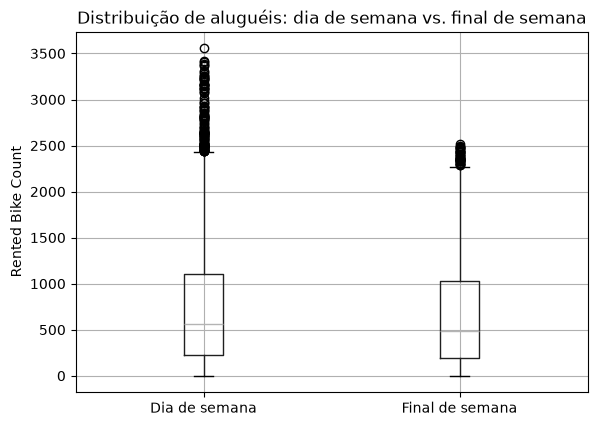

In [8]:
plt.figure(figsize=(6, 4))
df.boxplot(column="Rented Bike Count", by="IsWeekend")
plt.xticks([1, 2], ["Dia de semana", "Final de semana"])
plt.title("Distribuição de aluguéis: dia de semana vs. final de semana")
plt.suptitle("")
plt.ylabel("Rented Bike Count")
plt.xlabel("")
plt.show()

## 6. Conferência final e exportação

Conferimos o shape final, os tipos de dados e a ausência de nulos, e então salvamos o resultado em um **novo arquivo** (`SeoulBikeData_treated.csv`), preservando `SeoulBikeData.csv` intacto como backup.

In [9]:
print("Formato final:", df.shape)
print("\nValores ausentes por coluna:")
print(df.isnull().sum())
df.dtypes

Formato final: (8465, 14)

Valores ausentes por coluna:


Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
IsWeekend                    0
dtype: int64


Date                         datetime64[us]
Rented Bike Count                     int64
Hour                                  int64
Temperature(°C)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                      int64
Dew point temperature(°C)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                                 str
Holiday                                 str
IsWeekend                             int64
dtype: object

In [10]:
OUTPUT_PATH = "SeoulBikeData_treated.csv"

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
print(f"Dataset tratado salvo em: {OUTPUT_PATH}")
print(f"Backup original preservado em: {RAW_PATH}")

Dataset tratado salvo em: SeoulBikeData_treated.csv
Backup original preservado em: SeoulBikeData.csv
